In [1]:
import sys
sys.path.insert(0, '..')

# Fuzzy Cognitive Map (FCM) Library Example

This notebook demonstrates the basic functionality of the refactored `fcm` library. We will use the blood clot formation model from the original repository as an example.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from lib.fcm import FCM

%matplotlib inline

## 1. Define the FCM Structure

First, we define the concepts (nodes) and their causal relationships (weighted edges). The weights represent the strength and type (positive or negative) of the influence.

In [3]:
# The edge list defines the connections and their weights: (from, to, weight)
clot_edges = [
    (1, 1, 1), (1, 2, 0.4), (1, 3, 1), (1, 4, 1),
    (2, 3, 0.5), (2, 6, 0.45), (3, 2, 0.4), (3, 4, 0.75),
    (3, 6, 0.4), (4, 6, 0.4), (5, 6, 0.45), (6, 2, 0.7),
    (7, 5, -0.6), (8, 6, 0.95), (9, 10, -0.9), (10, 6, 1),
    (11, 8, 0.95), (12, 11, -0.6)
]

# The mapping provides descriptive labels for the integer nodes.
mapping = {
    1: "HCP", 2: "stas", 3: "inju", 4: "HCF", 5: "ADP", 6: "PAgg",
    7: "clop", 8: "A2", 9: "war", 10: "K", 11: "cox", 12: "aspi"
}

## 2. Create and Visualize the FCM

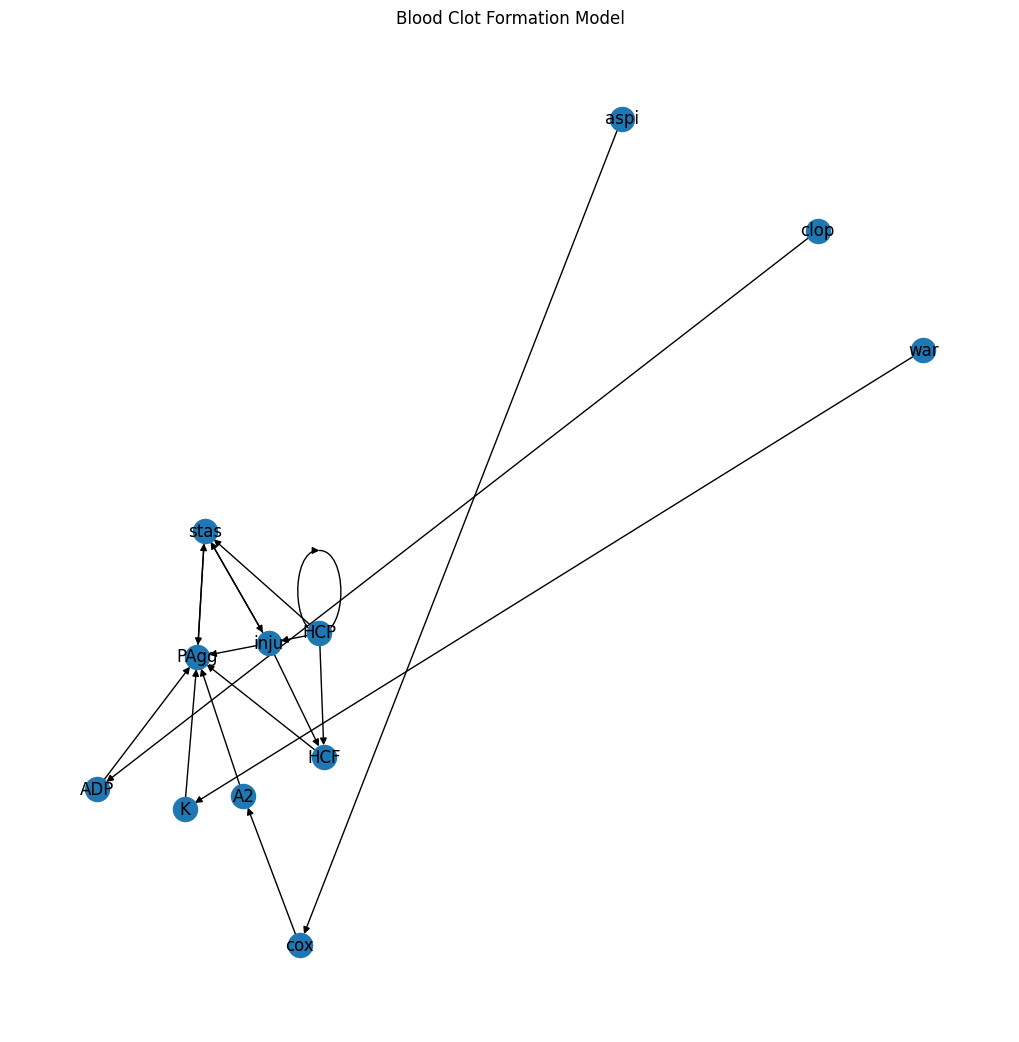

In [4]:
# Create an instance of the FCM class
clot_fcm = FCM("Blood Clot Formation Model")

# Add the weighted edges
clot_fcm.add_weighted_edges_from(clot_edges)

# Relabel the nodes to be more descriptive
nx.relabel_nodes(clot_fcm, mapping, copy=False)

# Visualize the graph
plt.figure(figsize=(10, 10))
clot_fcm.draw()
plt.show()

## 3. Evolve the FCM

Now, we'll set an initial state (activation vector) and let the system evolve until it reaches a stable state (a fixed point or a limit cycle).

In [5]:
# Get the node order from the graph to ensure our vector is correctly aligned
node_order = list(clot_fcm.nodes())

# Define an initial state. Let's activate 'inju' (injury) and 'aspi' (aspirin).
initial_state_map = {node: 1 if node in ["inju", "aspi"] else 0 for node in node_order}
initial_vector = np.array([initial_state_map[node] for node in node_order])

# Create a mask. For this example, we won't clamp any nodes.
mask = np.zeros_like(initial_vector)

print(f"Initial State ({', '.join(k for k,v in initial_state_map.items() if v==1)} active):")
print(initial_vector)

# Evolve the system
history = clot_fcm.evolve_to_limit(initial_vector, mask)

print("\nEvolution History:")
print(history)

Initial State (inju, aspi active):
[0 0 1 0 0 0 0 0 0 0 0 1]

Evolution History:
[[0 0 1 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]


The final row in the history matrix is the stable state that the system settled into.